# LLM-prompts Topic Classification

In [ ]:
!pip install -q datasets transformers scikit-learn torch

In [ ]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
from huggingface_hub import login

login()

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# model_name = "BAAI/bge-small-en-v1.5"
# model_name = 	"BAAI/bge-large-en"
model_name = "google/embeddinggemma-300m"



In [ ]:
LABEL_ORDER = [
    "Desktop & Mobile & Web Development",
    "Cybersecurity",
    "AI / Machine Learning / Data Science",
    "Infrastructure (DevOps, Cloud, Databases, Networking)",
    "Clinical Diagnosis, Treatment & Surgery",
    "Medication & Pharmacology",
    "Mental Health",
    "Healthcare Organizations, System, Hospitals",
    "Nutrition",
    "Payments & Personal Budgeting",
    "Investment, Markets & Cryptocurrency",
    "Corporate",
    "Physics, Mathematics",
    "Chemistry",
    "Biology",
    "Team Sports",
    "Individual Sports",
    "Fitness",
    "Civil, Structural & Architecture",
    "Mechanical & Electrical Engineering",
    "Family & Relationships",
    "Personal",
    "Travel",
    "Marketing & Sales",
    "Entrepreneurship & Startups",
    "Management & Strategy & Human Resources",
    "Criminal Law",
    "Family Law",
    "Corporate Law",
    "Civil Law" ,
    "Game",
    "Film",
    "Music",
    "Literature",
    "Painting",
]

In [ ]:
# Parent-to-Child Mapping Hierarchy
HIERARCHY = {
    "Programming / Technology": [
        "Desktop & Mobile & Web Development",
        "Cybersecurity",
        "AI / Machine Learning / Data Science",
        "Infrastructure (DevOps, Cloud, Databases, Networking)"
    ],
    "Medical": [
        "Clinical Diagnosis, Treatment & Surgery",
        "Medication & Pharmacology",
        "Mental Health",
        "Healthcare Organizations, System, Hospitals",
        "Nutrition"
    ],
    "Finance": [
        "Payments & Personal Budgeting",
        "Investment, Markets & Cryptocurrency",
        "Corporate"
    ],
    "Science": [
        "Physics, Mathematics",
        "Chemistry",
        "Biology"
    ],
    "Sports": [
        "Team Sports",
        "Individual Sports",
        "Fitness"
    ],
    "Engineering": [
        "Civil, Structural & Architecture",
        "Mechanical & Electrical Engineering",
    ],
    "Personal": [
        "Family & Relationships",
        "Personal",
        "Travel"
    ],
    "Business": [
        "Marketing & Sales",
        "Entrepreneurship & Startups",
        "Management & Strategy & Human Resources"
    ],
     "Law": [
        "Criminal Law",
        "Family Law",
        "Corporate Law",
        "Civil Law"
    ],
     "Art": [
        "Game",
        "Film",
        "Music",
        "Literature",
        "Painting"
    ],


}

# Invert mapping to find a parent from any child label
CHILD_TO_PARENT = {}
for parent, children in HIERARCHY.items():
    for child in children:
        CHILD_TO_PARENT[child] = parent

## Load dataset

In [ ]:
# Load dataset
dataset = load_dataset("maryamdar/topic_classification_dataset_gen")

README.md:   0%|          | 0.00/597 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.29MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/30445 [00:00<?, ? examples/s]

In [ ]:
dataset["train"] = dataset["train"].filter(lambda x: x["use_for_train"] is True)

Filter:   0%|          | 0/30445 [00:00<?, ? examples/s]

In [ ]:
dataset["train"] = dataset["train"].filter(
    lambda x: x["generator_model"] != "MiMo V2.5 Free"
)

Filter:   0%|          | 0/28636 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd

df = dataset["train"].to_pandas()

print("--- Dataset Info ---")
print(f"Total Rows: {len(df)}")
print(f"Columns: {list(df.columns)}\n")

# Missing (Null) Values
print("--- Missing Values ---")
print(df.isnull().sum())
print("\n" + "="*40 + "\n")

# Duplicate Text Entries
duplicate_texts = df.duplicated(subset=['text']).sum()
print("--- Duplicates ---")
print(f"Number of exact duplicate text rows: {duplicate_texts}")
print(f"Percentage of duplicates: {(duplicate_texts / len(df)) * 100:.2f}%")
print("\n" + "="*40 + "\n")

# Class Distribution (Rows per Label)
print("--- All Label Counts ---")
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts['Percentage'] = (label_counts['Count'] / len(df)) * 100

print(label_counts.to_string(index=False))

--- Dataset Info ---
Total Rows: 19935
Columns: ['text', 'old_label', 'old_parent_label', 'generator_model', 'source', 'generation_group', 'label', 'parent_label', 'use_for_train']

--- Missing Values ---
text                    0
old_label           12642
old_parent_label    12642
generator_model         0
source                  0
generation_group     2983
label                   0
parent_label            0
use_for_train           0
dtype: int64


--- Duplicates ---
Number of exact duplicate text rows: 0
Percentage of duplicates: 0.00%


--- All Label Counts ---
                                                Label  Count  Percentage
                   Desktop & Mobile & Web Development   1315    6.596438
                                        Cybersecurity   1013    5.081515
                                        Mental Health   1003    5.031352
          Healthcare Organizations, System, Hospitals    943    4.730374
                 AI / Machine Learning / Data Science    837    

In [ ]:
df = df.dropna(subset=['text', 'label'])
df = df.drop_duplicates(subset=['text'], keep='first')

## Label encoding

In [ ]:
from datasets import Dataset

# Fixed mapping
label_to_id = {label: i for i, label in enumerate(LABEL_ORDER)}
id_to_label = {i: label for label, i in label_to_id.items()}

# Encode labels
df["label_id"] = df["label"].map(label_to_id)

# Safety check
if df["label_id"].isna().any():
    missing = df[df["label_id"].isna()]["label"].unique()
    raise ValueError(f"Unknown labels found: {missing}")

print("Label Map:")
print(id_to_label)

# Convert back to HF Dataset
clean_dataset = Dataset.from_pandas(df, preserve_index=False)

Label Map:
{0: 'Desktop & Mobile & Web Development', 1: 'Cybersecurity', 2: 'AI / Machine Learning / Data Science', 3: 'Infrastructure (DevOps, Cloud, Databases, Networking)', 4: 'Clinical Diagnosis, Treatment & Surgery', 5: 'Medication & Pharmacology', 6: 'Mental Health', 7: 'Healthcare Organizations, System, Hospitals', 8: 'Nutrition', 9: 'Payments & Personal Budgeting', 10: 'Investment, Markets & Cryptocurrency', 11: 'Corporate', 12: 'Physics, Mathematics', 13: 'Chemistry', 14: 'Biology', 15: 'Team Sports', 16: 'Individual Sports', 17: 'Fitness', 18: 'Civil, Structural & Architecture', 19: 'Mechanical & Electrical Engineering', 20: 'Family & Relationships', 21: 'Personal', 22: 'Travel', 23: 'Marketing & Sales', 24: 'Entrepreneurship & Startups', 25: 'Management & Strategy & Human Resources', 26: 'Criminal Law', 27: 'Family Law', 28: 'Corporate Law', 29: 'Civil Law', 30: 'Game', 31: 'Film', 32: 'Music', 33: 'Literature', 34: 'Painting'}


## Train/Test Split

### Train and Test split of one dataset

In [ ]:
# from datasets import ClassLabel

# # Get the number of unique classes
# num_classes = len(df['label_id'].unique())

# # Cast 'label_id' to ClassLabel type
# clean_dataset = clean_dataset.cast_column("label_id", ClassLabel(num_classes=num_classes))

# # Now the stratified split will work smoothly
# split_dataset = clean_dataset.train_test_split(
#     test_size=0.2,
#     stratify_by_column="label_id",
#     seed=42
# )

# train_ds = split_dataset["train"]
# test_ds = split_dataset["test"]
# print(f"Train samples: {len(train_ds)} | Test samples: {len(test_ds)}")

### Different Train dataset and Test dataset

In [ ]:
# from datasets import ClassLabel

# # Get the number of unique classes
# num_classes = len(df['label_id'].unique())

# # Cast 'label_id' to ClassLabel type
# clean_dataset = clean_dataset.cast_column("label_id", ClassLabel(num_classes=num_classes))

# # Use the entire clean_dataset for training
# train_ds = clean_dataset
# print(f"Train samples: {len(train_ds)}")

Casting the dataset:   0%|          | 0/19935 [00:00<?, ? examples/s]

Train samples: 19935


#### Loading and Preparing the New Test Dataset

In [ ]:
# # Load the new test dataset from Hugging Face
# # Assuming the dataset to load is 'maryamdar/topic_classification_dataset_gen' and you want the 'test' split
# new_test_dataset = load_dataset("maryamdar/topic-classification-dataset-real-labeled", split="train")

# # Filter out rows where the label is 'Not Related'
# new_test_dataset = new_test_dataset.filter(lambda x: x["label"] != "Not Related")
# new_test_dataset = new_test_dataset.filter(lambda x: x["label"] != "Ambiguous")

# #other filters
# # new_test_dataset = new_test_dataset.filter(
# #     lambda x: x["confidence_score"] >= 0.9
# # )
# # new_test_dataset = new_test_dataset.filter(lambda x: x["source_dataset"] != "lavita/medical-qa-datasets")


# # Convert to pandas DataFrame for label encoding
# df_test = new_test_dataset.to_pandas()

# # Encode labels using the existing label_to_id mapping
# df_test["label_id"] = df_test["label"].map(label_to_id)

# # Safety check for unknown labels in the new test set
# if df_test["label_id"].isna().any():
#     missing = df_test[df_test["label_id"].isna()]["label"].unique()
#     print(f"Warning: Unknown labels found in the new test dataset: {missing}. These will be dropped.")
#     df_test = df_test.dropna(subset=["label_id"])

# # Convert back to Hugging Face Dataset and cast label_id
# test_ds = Dataset.from_pandas(df_test, preserve_index=False)
# test_ds = test_ds.cast_column("label_id", ClassLabel(num_classes=num_classes))

# print(f"New Test samples: {len(test_ds)}")

README.md:   0%|          | 0.00/517 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.07MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6997 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6997 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6130 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/4591 [00:00<?, ? examples/s]

New Test samples: 4591


### merge two datasets

In [ ]:
# Load the new test dataset from Hugging Face
# Assuming the dataset to load is 'maryamdar/topic_classification_dataset_gen' and you want the 'test' split
new_test_dataset = load_dataset("maryamdar/topic-classification-dataset-real-labeled", split="train")

# Filter out rows where the label is 'Not Related'
new_test_dataset = new_test_dataset.filter(lambda x: x["label"] != "Not Related")
new_test_dataset = new_test_dataset.filter(lambda x: x["label"] != "Ambiguous")

#other filters
# new_test_dataset = new_test_dataset.filter(
#     lambda x: x["confidence_score"] >= 0.9
# )
# new_test_dataset = new_test_dataset.filter(lambda x: x["source_dataset"] != "lavita/medical-qa-datasets")

README.md:   0%|          | 0.00/517 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.07MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6997 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6997 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6130 [00:00<?, ? examples/s]

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

TRAIN_SIZE = 1200
TEST_SIZE = 800
RANDOM_STATE = 42

# ============================================================
# Convert to pandas
# ============================================================

df_clean = clean_dataset.to_pandas()
df_new = new_test_dataset.to_pandas()


def stratified_split(df, train_size, test_size, name):
    """
    Stratified train/test sampling
    """

    # First take train
    df_train, df_remaining = train_test_split(
        df,
        train_size=train_size,
        stratify=df["label"],
        random_state=RANDOM_STATE
    )

    # Then take test from remaining
    df_test, _ = train_test_split(
        df_remaining,
        train_size=test_size,
        stratify=df_remaining["label"],
        random_state=RANDOM_STATE
    )

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"Total: {len(df)}")
    print(f"Train: {len(df_train)}")
    print(f"Test : {len(df_test)}")

    print("\nTrain label distribution:")
    print(df_train["label"].value_counts())

    print("\nTest label distribution:")
    print(df_test["label"].value_counts())

    return df_train, df_test


# ============================================================
# Split first dataset
# ============================================================

clean_train, clean_test = stratified_split(
    df_clean,
    TRAIN_SIZE,
    TEST_SIZE,
    "CLEAN DATASET"
)


# ============================================================
# Split second dataset
# ============================================================

new_train, new_test = stratified_split(
    df_new,
    TRAIN_SIZE,
    TEST_SIZE,
    "NEW DATASET"
)


# ============================================================
# Merge train and test separately
# ============================================================

train_merged = pd.concat(
    [
        clean_train,
        new_train
    ],
    ignore_index=True
)


test_merged = pd.concat(
    [
        clean_test,
        new_test
    ],
    ignore_index=True
)


# ============================================================
# Final checks
# ============================================================

print("\n\nFINAL MERGED DATA")
print("=" * 60)

print(f"Train merged size: {len(train_merged)}")
print(f"Test merged size : {len(test_merged)}")


print("\nMerged train labels:")
print(train_merged["label"].value_counts())


print("\nMerged test labels:")
print(test_merged["label"].value_counts())

CLEAN DATASET
Total: 19935
Train: 1200
Test : 800

Train label distribution:
label
Desktop & Mobile & Web Development                       79
Cybersecurity                                            61
Mental Health                                            60
Healthcare Organizations, System, Hospitals              57
AI / Machine Learning / Data Science                     50
Clinical Diagnosis, Treatment & Surgery                  48
Infrastructure (DevOps, Cloud, Databases, Networking)    46
Investment, Markets & Cryptocurrency                     42
Medication & Pharmacology                                41
Nutrition                                                36
Music                                                    35
Fitness                                                  33
Marketing & Sales                                        32
Mechanical & Electrical Engineering                      31
Family & Relationships                                   31
Biology          

In [ ]:
from datasets import Dataset

# ============================================================
# Convert merged pandas back to Hugging Face Dataset
# ============================================================

train_ds = Dataset.from_pandas(
    train_merged,
    preserve_index=False
)

test_ds = Dataset.from_pandas(
    test_merged,
    preserve_index=False
)


# ============================================================
# Final verification
# ============================================================

print(train_ds)
print(test_ds)

print("\nTrain label counts:")
print(pd.Series(train_ds["label"]).value_counts())

print("\nTest label counts:")
print(pd.Series(test_ds["label"]).value_counts())

Dataset({
    features: ['text', 'old_label', 'old_parent_label', 'generator_model', 'source', 'generation_group', 'label', 'parent_label', 'use_for_train', 'label_id', 'confidence_score', 'source_dataset'],
    num_rows: 2400
})
Dataset({
    features: ['text', 'old_label', 'old_parent_label', 'generator_model', 'source', 'generation_group', 'label', 'parent_label', 'use_for_train', 'label_id', 'confidence_score', 'source_dataset'],
    num_rows: 1600
})

Train label counts:
Desktop & Mobile & Web Development                       242
Clinical Diagnosis, Treatment & Surgery                  190
AI / Machine Learning / Data Science                     137
Civil Law                                                123
Physics, Mathematics                                     113
Mechanical & Electrical Engineering                       99
Chemistry                                                 91
Literature                                                86
Cybersecurity                  

In [ ]:
from datasets import Dataset

# Fixed mapping (same as before)
label_to_id = {label: i for i, label in enumerate(LABEL_ORDER)}
id_to_label = {i: label for label, i in label_to_id.items()}


def encode_labels(example):
    example["label_id"] = label_to_id[example["label"]]
    return example


# Encode both datasets
train_ds = train_ds.map(encode_labels)
test_ds = test_ds.map(encode_labels)


print("Label Map:")
print(id_to_label)


# Check
print(train_ds[0])
print(test_ds[0])

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Label Map:
{0: 'Desktop & Mobile & Web Development', 1: 'Cybersecurity', 2: 'AI / Machine Learning / Data Science', 3: 'Infrastructure (DevOps, Cloud, Databases, Networking)', 4: 'Clinical Diagnosis, Treatment & Surgery', 5: 'Medication & Pharmacology', 6: 'Mental Health', 7: 'Healthcare Organizations, System, Hospitals', 8: 'Nutrition', 9: 'Payments & Personal Budgeting', 10: 'Investment, Markets & Cryptocurrency', 11: 'Corporate', 12: 'Physics, Mathematics', 13: 'Chemistry', 14: 'Biology', 15: 'Team Sports', 16: 'Individual Sports', 17: 'Fitness', 18: 'Civil, Structural & Architecture', 19: 'Mechanical & Electrical Engineering', 20: 'Family & Relationships', 21: 'Personal', 22: 'Travel', 23: 'Marketing & Sales', 24: 'Entrepreneurship & Startups', 25: 'Management & Strategy & Human Resources', 26: 'Criminal Law', 27: 'Family Law', 28: 'Corporate Law', 29: 'Civil Law', 30: 'Game', 31: 'Film', 32: 'Music', 33: 'Literature', 34: 'Painting'}
{'text': 'how to pitch investors', 'old_label':

### train and test class distribution

In [ ]:
train_ds[0]

{'text': 'how to pitch investors',
 'old_label': 'Entrepreneurship & Startups',
 'old_parent_label': 'Business',
 'generator_model': 'deepseek-v4',
 'source': 'generated',
 'generation_group': '36_labels_1',
 'label': 'Entrepreneurship & Startups',
 'parent_label': 'Business',
 'use_for_train': True,
 'label_id': 24.0,
 'confidence_score': None,
 'source_dataset': None}

In [ ]:
import pandas as pd
df = train_ds.to_pandas()

# Class Distribution (Rows per Label)
print("--- Train Label Counts ---")
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts['Percentage'] = (label_counts['Count'] / len(df)) * 100

print(label_counts.to_string(index=False))

--- Train Label Counts ---
                                                Label  Count  Percentage
                   Desktop & Mobile & Web Development    242   10.083333
              Clinical Diagnosis, Treatment & Surgery    190    7.916667
                 AI / Machine Learning / Data Science    137    5.708333
                                            Civil Law    123    5.125000
                                 Physics, Mathematics    113    4.708333
                  Mechanical & Electrical Engineering     99    4.125000
                                            Chemistry     91    3.791667
                                           Literature     86    3.583333
                                        Cybersecurity     84    3.500000
Infrastructure (DevOps, Cloud, Databases, Networking)     69    2.875000
                                        Mental Health     69    2.875000
                                              Fitness     63    2.625000
                        

In [ ]:
import pandas as pd
df = test_ds.to_pandas()

# Class Distribution (Rows per Label)
print("--- Test Label Counts ---")
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts['Percentage'] = (label_counts['Count'] / len(df)) * 100

print(label_counts.to_string(index=False))

--- Test Label Counts ---
                                                Label  Count  Percentage
                   Desktop & Mobile & Web Development    162     10.1250
              Clinical Diagnosis, Treatment & Surgery    126      7.8750
                 AI / Machine Learning / Data Science     92      5.7500
                                            Civil Law     83      5.1875
                                 Physics, Mathematics     75      4.6875
                  Mechanical & Electrical Engineering     66      4.1250
                                            Chemistry     61      3.8125
                                           Literature     58      3.6250
                                        Cybersecurity     56      3.5000
                                        Mental Health     46      2.8750
Infrastructure (DevOps, Cloud, Databases, Networking)     46      2.8750
                                              Fitness     42      2.6250
                         

## Preprocessing & Embeddings

In [ ]:
# # mean pooling helper
# def mean_pooling(model_output, attention_mask):
#     token_embeddings = model_output[0]
#     input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
#     return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

In [ ]:
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = AutoModel.from_pretrained(model_name).to(device)
# model.eval()

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  133MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 384, padding_idx=0)
    (position_embeddings): Embedding(512, 384)
    (token_type_embeddings): Embedding(2, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
# # Batch processing function
# def extract_embeddings(batch):
#     encoded_input = tokenizer(
#         batch["text"],
#         padding=True,
#         truncation=True,
#         max_length=2048,
#         return_tensors="pt"
#     ).to(device)

#     with torch.no_grad():
#         model_output = model(**encoded_input)

#     sentence_embeddings = mean_pooling(model_output, encoded_input["attention_mask"])
#     sentence_embeddings = torch.nn.functional.normalize(sentence_embeddings, p=2, dim=1)

#     return {"embedding": sentence_embeddings.cpu().numpy()}

In [ ]:
# # embedding extraction
# train_embedded = train_ds.map(extract_embeddings, batched=True, batch_size=32)
# test_embedded = test_ds.map(extract_embeddings, batched=True, batch_size=32)

Map:   0%|          | 0/19935 [00:00<?, ? examples/s]

Map:   0%|          | 0/4591 [00:00<?, ? examples/s]

RuntimeError: The size of tensor a (556) must match the size of tensor b (512) at non-singleton dimension 1

In [ ]:
# # Convert features and target labels into numpy arrays
# X_train = np.array(train_embedded["embedding"])
# y_train = np.array(train_embedded["label_id"])

# X_test = np.array(test_embedded["embedding"])
# y_test = np.array(test_embedded["label_id"])

In [ ]:
# y_train[0]

np.int64(2)

In [ ]:
# X_train[0].shape

(768,)

## Gemma Sentence Transformr

In [ ]:
from sentence_transformers import SentenceTransformer
# model = SentenceTransformer(
#     "google/embeddinggemma-300m",
#     model_kwargs={"torch_dtype": torch.float32},  # do not use float16
# )
model = SentenceTransformer(
    "google/embeddinggemma-300m",
    model_kwargs={"torch_dtype": torch.float32},
    device=device
)
# model = SentenceTransformer(
#     model_name,
#     model_kwargs={"torch_dtype": torch.float32},
#     device=device
# )

model.eval()

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'Gemma3TextModel'})
  (1): Pooling({'embedding_dimension': 768, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Dense({'in_features': 768, 'out_features': 3072, 'bias': False, 'activation_function': 'torch.nn.modules.linear.Identity', 'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
  (3): Dense({'in_features': 3072, 'out_features': 768, 'bias': False, 'activation_function': 'torch.nn.modules.linear.Identity', 'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
  (4): Normalize({})
)

In [ ]:
def extract_embeddings(batch):
    # texts = [
    #     f"task: classification | query: {text}"
    #     for text in batch["text"]
    # ]

    embeddings = model.encode(
        batch["text"],
        prompt_name="Classification",
        # batch_size=len(texts),
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False
    )

    return {"embedding": embeddings}

In [ ]:
train_embedded = train_ds.map(
    extract_embeddings,
    batched=True,
    batch_size=32
)

test_embedded = test_ds.map(
    extract_embeddings,
    batched=True,
    batch_size=32
)

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

In [ ]:
# Convert features and target labels into numpy arrays
X_train = np.array(train_embedded["embedding"])
y_train = np.array(train_embedded["label_id"])

X_test = np.array(test_embedded["embedding"])
y_test = np.array(test_embedded["label_id"])

## Train Classifier

In [ ]:
# classifier = LogisticRegression(max_iter=1000, C=1.0)
# classifier.fit(X_train, y_train)

ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

Epoch 01/10 | Loss: 0.5988 | Accuracy: 0.8979
Epoch 02/10 | Loss: 0.4542 | Accuracy: 0.9479
Epoch 03/10 | Loss: 0.4373 | Accuracy: 0.9504
Epoch 04/10 | Loss: 0.4119 | Accuracy: 0.9513
Epoch 05/10 | Loss: 0.4091 | Accuracy: 0.9579
Epoch 06/10 | Loss: 0.4570 | Accuracy: 0.9542
Epoch 07/10 | Loss: 0.4366 | Accuracy: 0.9654
Epoch 08/10 | Loss: 0.4303 | Accuracy: 0.9617
Epoch 09/10 | Loss: 0.4431 | Accuracy: 0.9613
Epoch 10/10 | Loss: 0.4193 | Accuracy: 0.9621


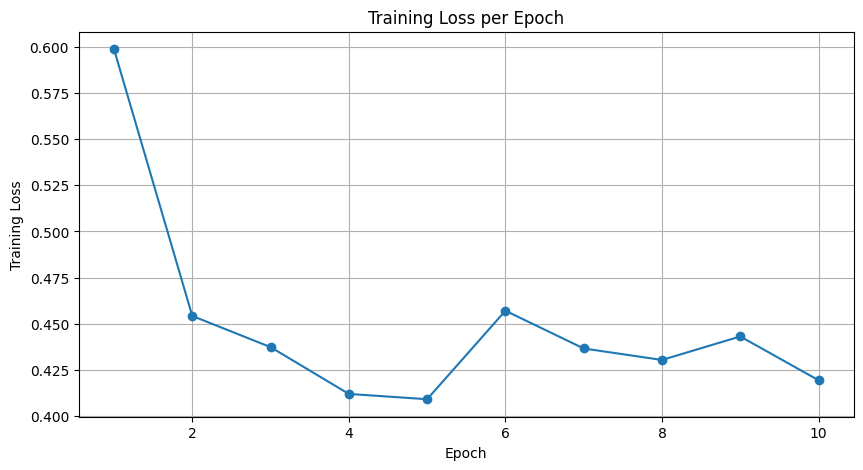

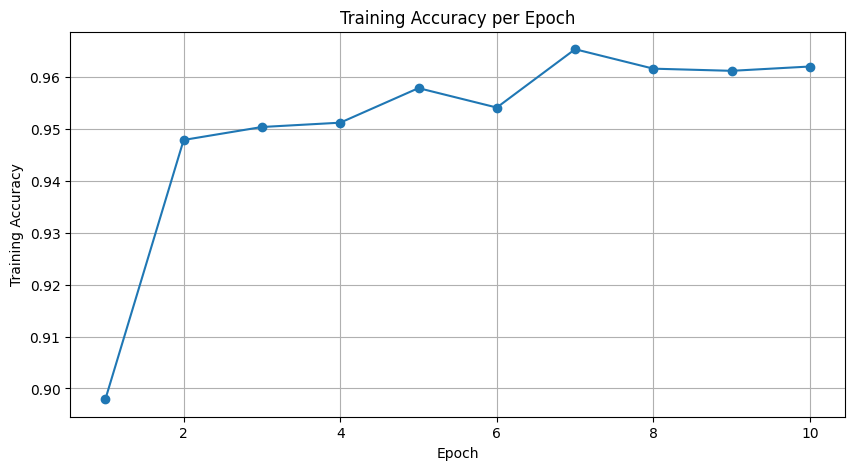

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score

# ============================================================
# MODEL
# ============================================================

classifier = SGDClassifier(
    loss="log_loss",       # Logistic Regression
    max_iter=1,            # We manually control epochs
    learning_rate="optimal",
    random_state=42
)

# ============================================================
# TRAINING
# ============================================================

EPOCHS =10

train_losses = []
train_accuracies = []

classes = np.unique(y_train)

for epoch in range(EPOCHS):

    # Shuffle data every epoch
    indices = np.random.permutation(len(X_train))

    X_epoch = X_train[indices]
    y_epoch = y_train.iloc[indices] if hasattr(y_train, "iloc") else y_train[indices]

    # One epoch
    classifier.partial_fit(
        X_epoch,
        y_epoch,
        classes=classes
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_train_pred = classifier.predict(X_train)
    y_train_prob = classifier.predict_proba(X_train)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    loss = log_loss(
        y_train,
        y_train_prob,
        labels=classes
    )

    accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    train_losses.append(loss)
    train_accuracies.append(accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Loss: {loss:.4f} | "
        f"Accuracy: {accuracy:.4f}"
    )

# ============================================================
# PLOTS
# ============================================================

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss per Epoch")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy per Epoch")
plt.grid(True)
plt.show()

## save classifier as joblib

In [ ]:
import joblib
import json

# Save trained classifier
joblib.dump(classifier, "classifier.joblib")

# Save label mappings
id_to_label = {i: label for label, i in label_to_id.items()}
with open("label_mappings.json", "w") as f:
    json.dump({"id_to_label": {str(k): v for k, v in id_to_label.items()}}, f)

## Evaluation Plots and Report


In [ ]:
def predict_model(classifier, X_test):
    return classifier.predict(X_test)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

In [ ]:
def show_classification_report(
    y_test,
    y_pred,
    label_order,
    save_report=False,
):
    label_ids = list(range(len(label_order)))

    report = classification_report(
        y_test,
        y_pred,
        labels=label_ids,
        target_names=label_order,
        output_dict=True,
        zero_division=0,
    )

    print("\n--- Model Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

    print(
        classification_report(
            y_test,
            y_pred,
            labels=label_ids,
            target_names=label_order,
            zero_division=0,
        )
    )

    summary = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Macro F1-Score",
            "Weighted F1-Score",
        ],
        "Test": [
            accuracy_score(y_test, y_pred),
            f1_score(y_test, y_pred, average="macro"),
            f1_score(y_test, y_pred, average="weighted"),
        ],
    })

    summary["Test"] = summary["Test"].map("{:.2%}".format)

    display(summary)

    return report

In [ ]:
def plot_child_confusion_matrix_old(
    y_test,
    y_pred,
    label_order,
    save_path="confusion_matrix.png",
):
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=list(range(len(label_order))),
    )

    fig_size = min(max(8, len(label_order) * 0.8), 16)

    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_order,
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False,
    )

    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(
        label_order,
        rotation=45,
        ha="right",
        fontsize=9,
    )

    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(
        label_order,
        fontsize=9,
    )

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )
        print(f"Saved to {save_path}")

    plt.title("child_confusion_matrix")
    plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


def plot_child_confusion_matrix(
    y_test,
    y_pred,
    label_order,
    save_path="confusion_matrix.png",
):
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=list(range(len(label_order))),
    )

    # Convert each row to percentages
    row_sums = cm.sum(axis=1, keepdims=True)

    cm_percent = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0,
    ) * 100

    fig_size = min(max(8, len(label_order) * 0.8), 16)

    fig, ax = plt.subplots(
        figsize=(fig_size, fig_size)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_percent,
        display_labels=label_order,
    )

    disp.plot(
        cmap="Blues",
        values_format=".1f",
        ax=ax,
        colorbar=False,
    )

    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(
        label_order,
        rotation=45,
        ha="right",
        fontsize=9,
    )

    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(
        label_order,
        fontsize=9,
    )

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.title("child_confusion_matrix")
    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )
        print(f"Saved to {save_path}")

    plt.show()
    plt.close(fig)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


def plot_misclassification_confusion_matrix(
    y_test,
    y_pred,
    label_order,
    save_path="misclassification_confusion_matrix.png",
):
    # --------------------------------------------------
    # Create confusion matrix with raw counts
    # --------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=list(range(len(label_order))),
    )

    # --------------------------------------------------
    # Remove correct classifications
    # --------------------------------------------------

    # Set diagonal to 0
    np.fill_diagonal(cm, 0)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig_size = min(max(8, len(label_order) * 0.8), 16)

    fig, ax = plt.subplots(
        figsize=(fig_size, fig_size)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_order,
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False,
    )

    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(
        label_order,
        rotation=45,
        ha="right",
        fontsize=9,
    )

    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(
        label_order,
        fontsize=9,
    )

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    ax.set_title("Misclassification Confusion Matrix")

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )
        print(f"Saved to {save_path}")

    plt.show()
    plt.close(fig)

In [ ]:
def show_parent_summary(report, hierarchy):
    rows = []

    for parent, children in hierarchy.items():

        precision = []
        recall = []
        f1 = []
        support = []

        for child in children:
            cls = report[child]

            precision.append(cls["precision"])
            recall.append(cls["recall"])
            f1.append(cls["f1-score"])
            support.append(cls["support"])

        rows.append({
            "Parent": parent,

            "Precision Min": min(precision),
            "Precision Avg": np.mean(precision),
            "Precision Max": max(precision),

            "Recall Min": min(recall),
            "Recall Avg": np.mean(recall),
            "Recall Max": max(recall),

            "F1 Min": min(f1),
            "F1 Avg": np.mean(f1),
            "F1 Max": max(f1),

            "Support": sum(support),
        })

    df = pd.DataFrame(rows)

    for c in df.columns:
        if c not in ["Parent", "Support"]:
            df[c] = df[c].map("{:.2%}".format)

    display(df)

In [ ]:
def plot_parent_misclassification_matrix(
    y_test,
    y_pred,
    hierarchy,
    id_to_label,
    save_path=None,
):
    # Child -> Parent mapping
    child_to_parent = {
        child: parent
        for parent, children in hierarchy.items()
        for child in children
    }

    parent_names = list(hierarchy.keys())

    # Initialize matrix
    parent_missclass_cm = pd.DataFrame(
        0,
        index=parent_names,
        columns=parent_names
    )

    # Check every child-level mistake
    for true_id, pred_id in zip(y_test, y_pred):

        true_child = id_to_label[true_id]
        pred_child = id_to_label[pred_id]

        # Ignore correct child predictions
        if true_child == pred_child:
            continue

        true_parent = child_to_parent[true_child]
        pred_parent = child_to_parent[pred_child]

        # Count this mistake at parent level
        parent_missclass_cm.loc[
            true_parent,
            pred_parent
        ] += 1


    cm = parent_missclass_cm.values


    fig_size = max(10, len(parent_names) * 0.7)

    fig, ax = plt.subplots(
        figsize=(fig_size, fig_size)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=parent_names,
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False,
    )

    ax.set_xlabel(
        "Predicted Parent (from wrong child prediction)"
    )

    ax.set_ylabel(
        "True Parent (where mistake happened)"
    )

    ax.set_title(
        "Parent-Level Misclassification Matrix\n(Number of Child-Level Errors)"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    return parent_missclass_cm

In [ ]:
import numpy as np


def show_random_misclassified_probabilities(
    y_test,
    y_pred,
    probabilities,
    class_ids,
    id_to_label,
    n_samples=15,
    top_k=10,
    random_state=None,
):
    """
    Show top-k class probabilities for random misclassified samples.

    Uses already-computed y_pred and probabilities.
    Does NOT run prediction again.
    """

    y_test = np.asarray(y_test)
    y_pred = np.asarray(y_pred)

    # ------------------------------------------------------------
    # Find misclassified samples
    # ------------------------------------------------------------

    misclassified_indices = np.where(
        y_test != y_pred
    )[0]

    if len(misclassified_indices) == 0:
        print("No misclassified samples!")
        return

    # ------------------------------------------------------------
    # Randomly select misclassified samples
    # ------------------------------------------------------------

    rng = np.random.default_rng(random_state)

    n_to_show = min(
        n_samples,
        len(misclassified_indices)
    )

    selected_indices = rng.choice(
        misclassified_indices,
        size=n_to_show,
        replace=False,
    )

    # ------------------------------------------------------------
    # Display
    # ------------------------------------------------------------

    print("=" * 100)
    print(
        f"Showing {n_to_show} random misclassified samples "
        f"out of {len(misclassified_indices)}"
    )
    print("=" * 100)

    for number, idx in enumerate(selected_indices, start=1):

        true_id = y_test[idx]
        pred_id = y_pred[idx]

        true_label = id_to_label.get(
            true_id,
            str(true_id)
        )

        pred_label = id_to_label.get(
            pred_id,
            str(pred_id)
        )

        sample_probs = probabilities[idx]

        # --------------------------------------------------------
        # Sort ALL classes by probability
        # --------------------------------------------------------

        sorted_indices = np.argsort(
            sample_probs
        )[::-1]

        # Only display top K
        top_indices = sorted_indices[:top_k]

        print(f"\n{'─' * 100}")
        print(f"Sample {number}  |  Test index: {idx}")
        print(f"{'─' * 100}")

        print(f"True label     : {true_label}")
        print(f"Predicted label: {pred_label}")

        print(f"\nTop {top_k} probabilities:")

        for rank, prob_idx in enumerate(top_indices, start=1):

            class_id = class_ids[prob_idx]

            label = id_to_label.get(
                class_id,
                str(class_id)
            )

            probability = sample_probs[prob_idx]

            # Mark true and predicted classes
            marker = ""

            if class_id == true_id:
                marker = " <-- TRUE"

            elif class_id == pred_id:
                marker = " <-- PREDICTED"

            print(
                f"{rank:2d}. "
                f"{label:<40} "
                f"{probability:.4f} "
                f"({probability * 100:6.2f}%)"
                f"{marker}"
            )

    return selected_indices

In [ ]:
import numpy as np


def save_test_results(
    path,
    y_test,
    y_pred,
    probabilities,
    class_ids,
):
    np.savez_compressed(
        path,
        y_test=np.asarray(y_test),
        y_pred=np.asarray(y_pred),
        probabilities=np.asarray(probabilities),
        class_ids=np.asarray(class_ids),
    )

    print(f"Saved test results to: {path}")

In [ ]:
def load_test_results(path):
    data = np.load(path)

    return (
        data["y_test"],
        data["y_pred"],
        data["probabilities"],
        data["class_ids"],
    )

In [ ]:
def evaluate_model(
    X_test,
    y_test,
    label_order,
    id_to_label,
    hierarchy,
    classifier=None,
    save_path="test_predictions.npz",
    n_misclassified=15,
    random_state=42,
):

    # ============================================================
    # PREDICT ONCE
    # ============================================================

    y_pred = classifier.predict(X_test)

    # ============================================================
    # PROBABILITIES ONCE
    # ============================================================

    probabilities = classifier.predict_proba(X_test)
    # import joblib
    # import json

    # classifier = joblib.load("classifier.joblib")
    # y_test, y_pred, probabilities, class_ids = load_test_results(
    #   "test_predictions.npz"
    # )

    class_ids = classifier.classes_

    # ============================================================
    # SAVE EVERYTHING
    # ============================================================

    save_test_results(
        save_path,
        y_test,
        y_pred,
        probabilities,
        class_ids,
    )

    # ============================================================
    # ALL EVALUATION USES THE SAME y_pred
    # ============================================================

    report = show_classification_report(
        y_test,
        y_pred,
        label_order,
    )

    plot_child_confusion_matrix_old(
        y_test,
        y_pred,
        label_order,
    )

    plot_child_confusion_matrix(
        y_test,
        y_pred,
        label_order,
    )

    plot_misclassification_confusion_matrix(
        y_test,
        y_pred,
        label_order,
    )

    show_parent_summary(
        report,
        hierarchy,
    )

    plot_parent_misclassification_matrix(
        y_test,
        y_pred,
        hierarchy,
        id_to_label,
    )

    # ============================================================
    # SHOW RANDOM MISCLASSIFICATIONS
    # USING THE SAME y_pred + probabilities
    # ============================================================

    show_random_misclassified_probabilities(
        y_test=y_test,
        y_pred=y_pred,
        probabilities=probabilities,
        class_ids=class_ids,
        id_to_label=id_to_label,
        n_samples=n_misclassified,
        random_state=random_state,
    )

    return y_pred, probabilities

## Evaluate Normal

Saved test results to: test_predictions.npz

--- Model Evaluation ---
Accuracy: 89.31%

                                                       precision    recall  f1-score   support

                   Desktop & Mobile & Web Development       0.87      0.94      0.90       162
                                        Cybersecurity       0.88      0.91      0.89        56
                 AI / Machine Learning / Data Science       0.93      0.83      0.87        92
Infrastructure (DevOps, Cloud, Databases, Networking)       0.88      0.76      0.81        46
              Clinical Diagnosis, Treatment & Surgery       0.92      0.97      0.94       126
                            Medication & Pharmacology       0.95      0.88      0.91        40
                                        Mental Health       1.00      0.89      0.94        46
          Healthcare Organizations, System, Hospitals       1.00      0.95      0.97        40
                                            Nutrition   

,Metric,Test
0,Accuracy,89.31%
1,Macro F1-Score,89.01%
2,Weighted F1-Score,89.29%


Saved to confusion_matrix.png


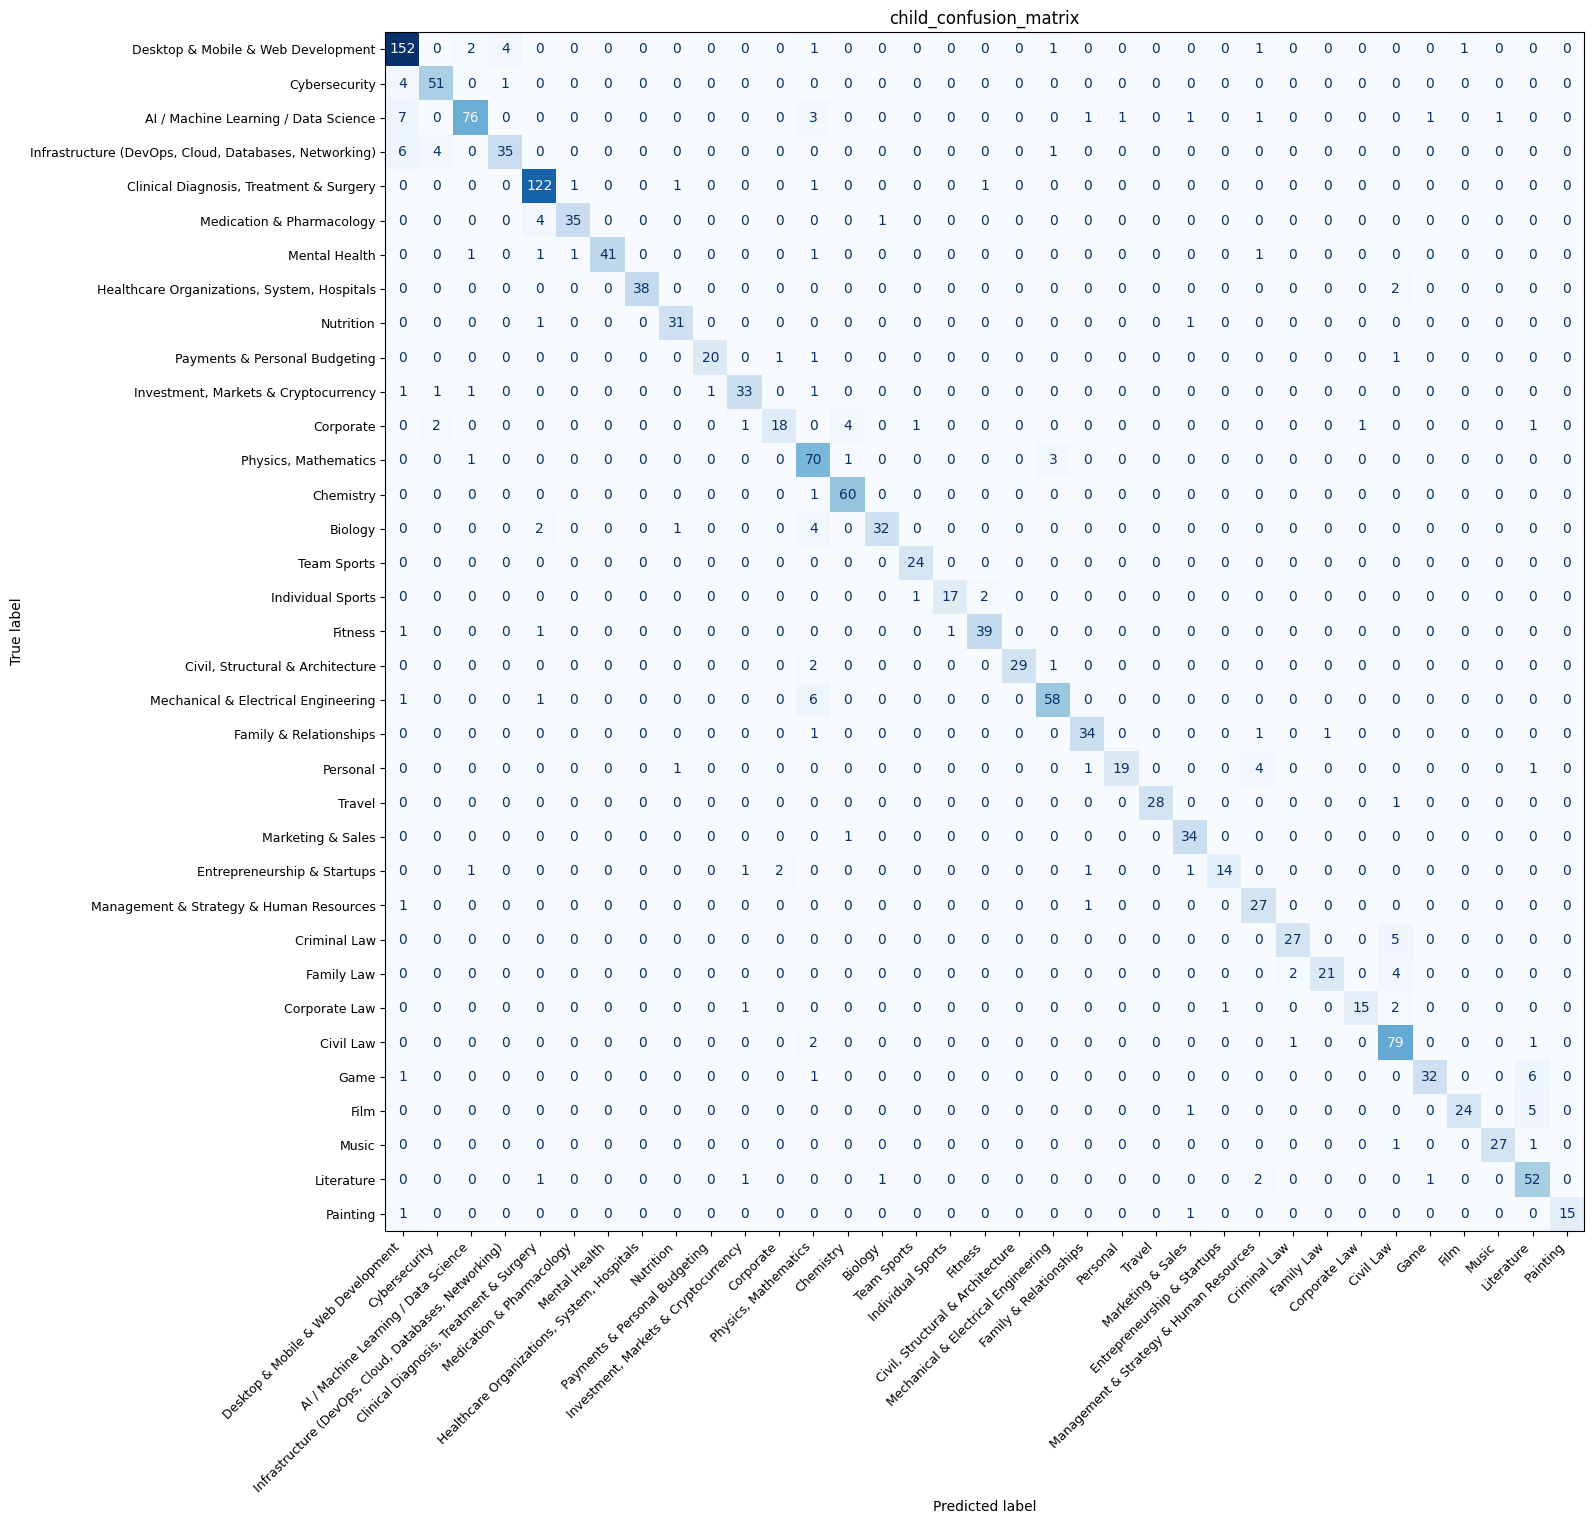

Saved to confusion_matrix.png


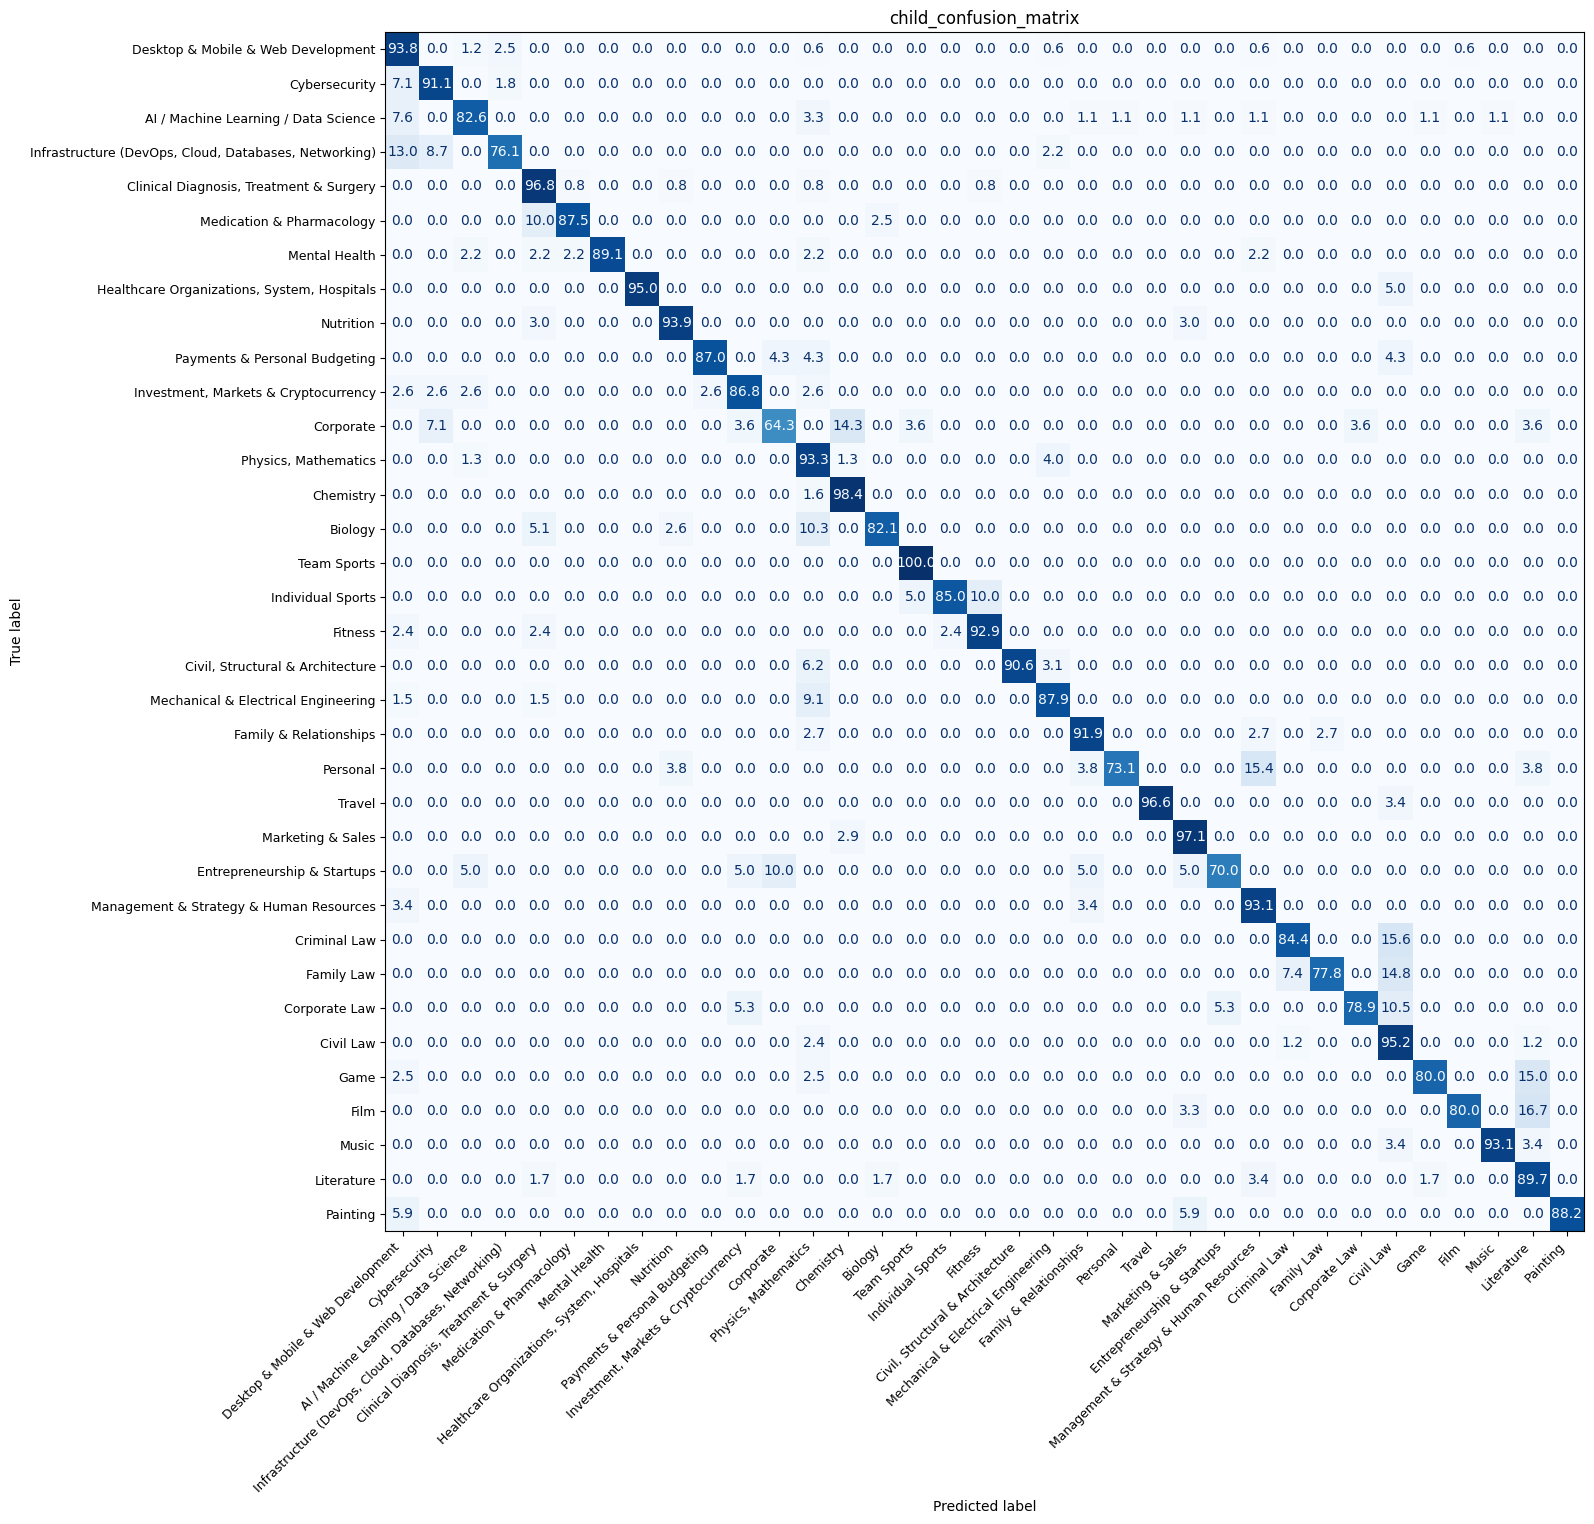

Saved to misclassification_confusion_matrix.png


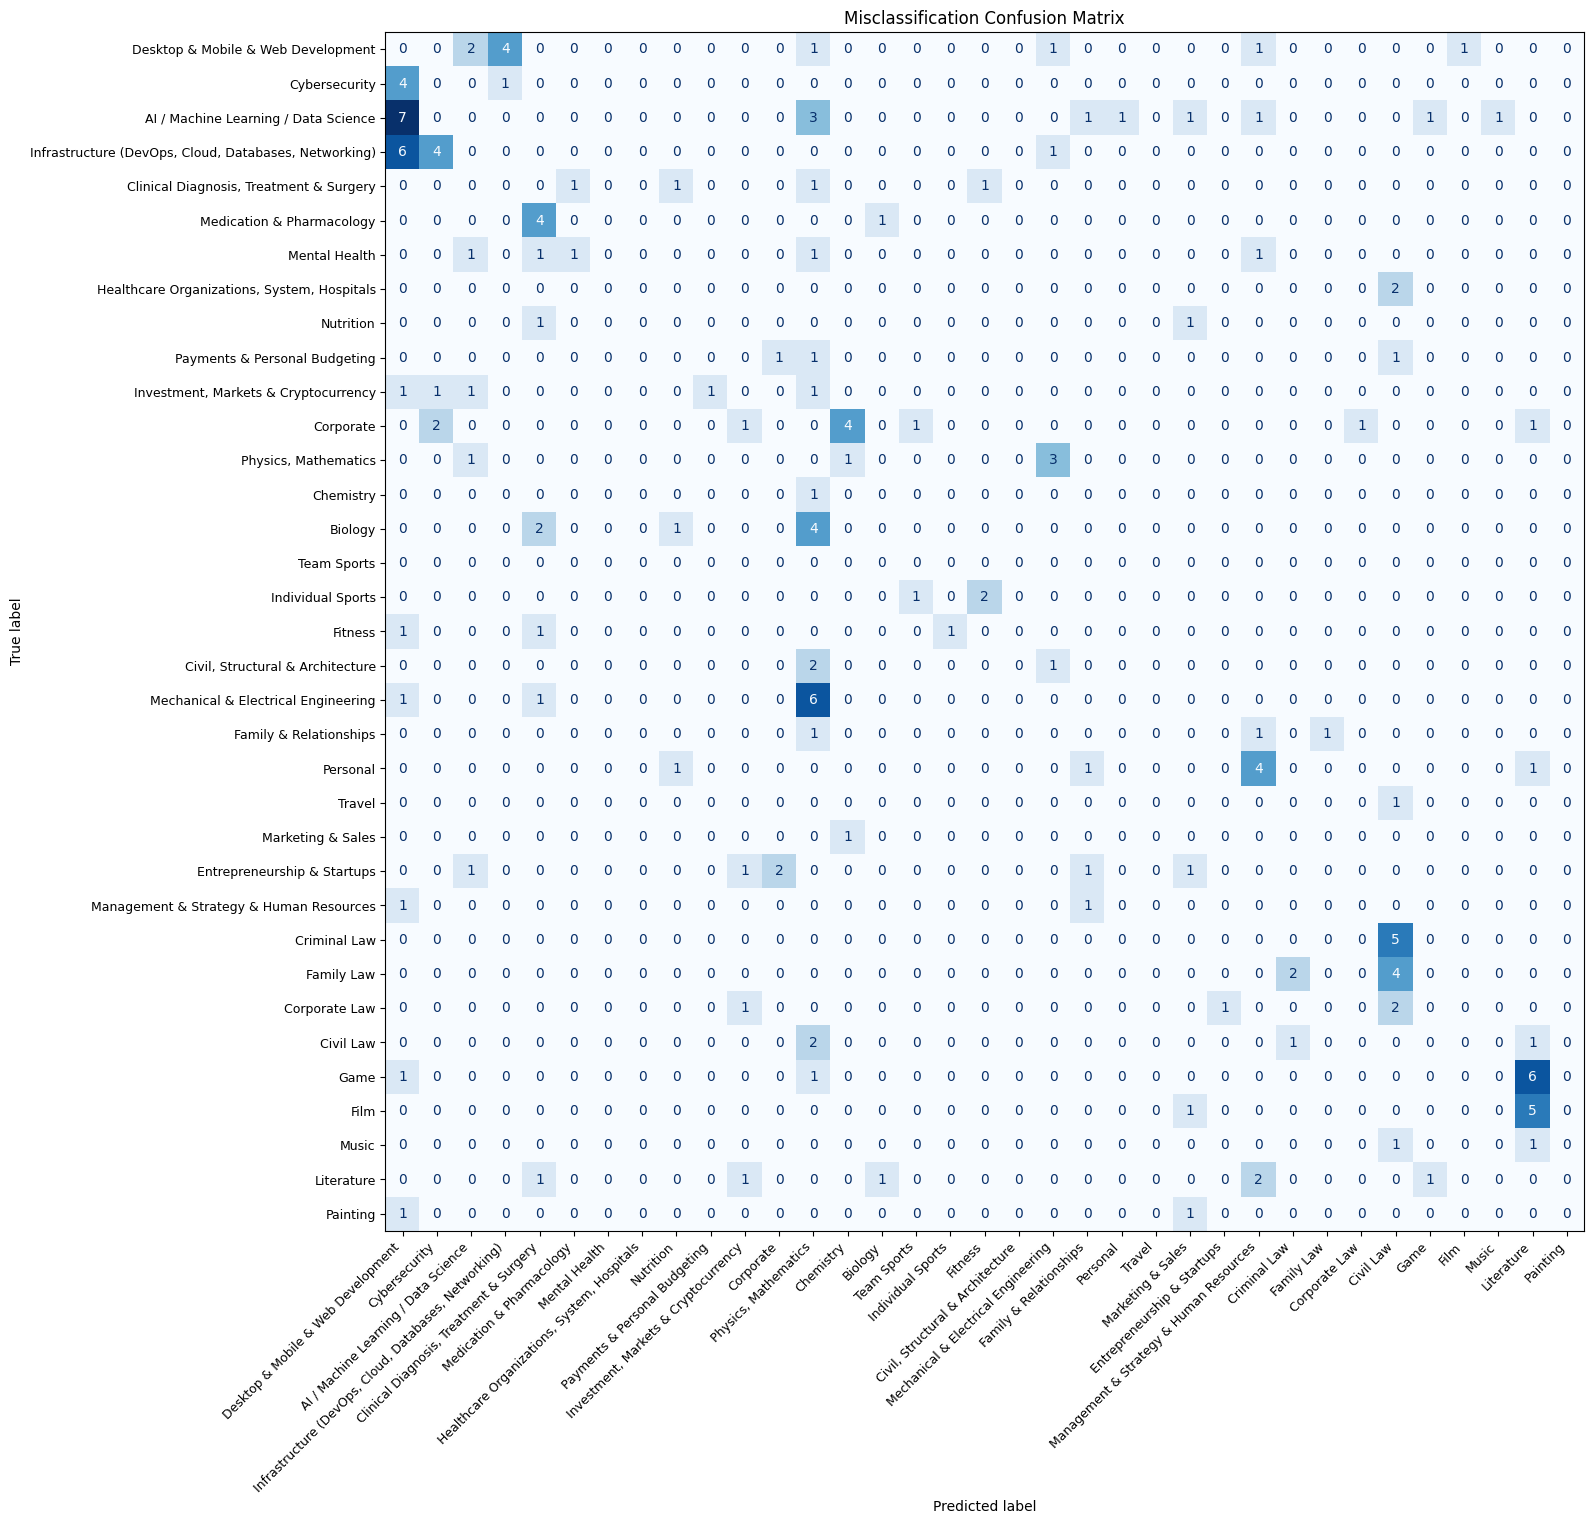

,Parent,Precision Min,Precision Avg,Precision Max,Recall Min,Recall Avg,Recall Max,F1 Min,F1 Avg,F1 Max,Support
0,Programming / Technology,86.86%,88.74%,92.68%,76.09%,85.90%,93.83%,81.40%,87.11%,90.21%,356.0
1,Medical,91.18%,95.50%,100.00%,87.50%,92.48%,96.83%,90.91%,93.87%,97.44%,285.0
2,Finance,85.71%,90.05%,95.24%,64.29%,79.36%,86.96%,73.47%,84.13%,90.91%,89.0
3,Science,73.68%,86.24%,94.12%,82.05%,91.25%,98.36%,82.35%,88.17%,94.49%,175.0
4,Sports,92.31%,93.20%,94.44%,85.00%,92.62%,100.00%,89.47%,92.78%,96.00%,86.0
5,Engineering,90.62%,95.31%,100.00%,87.88%,89.25%,90.62%,89.23%,92.16%,95.08%,98.0
6,Personal,89.47%,94.82%,100.00%,73.08%,87.17%,96.55%,82.61%,90.51%,98.25%,92.0
7,Business,72.97%,84.50%,93.33%,70.00%,86.75%,97.14%,80.00%,84.57%,91.89%,84.0
8,Law,83.16%,90.59%,95.45%,77.78%,84.07%,95.18%,85.71%,86.82%,88.76%,161.0
9,Art,77.61%,92.83%,100.00%,80.00%,86.20%,93.10%,83.20%,89.09%,94.74%,174.0


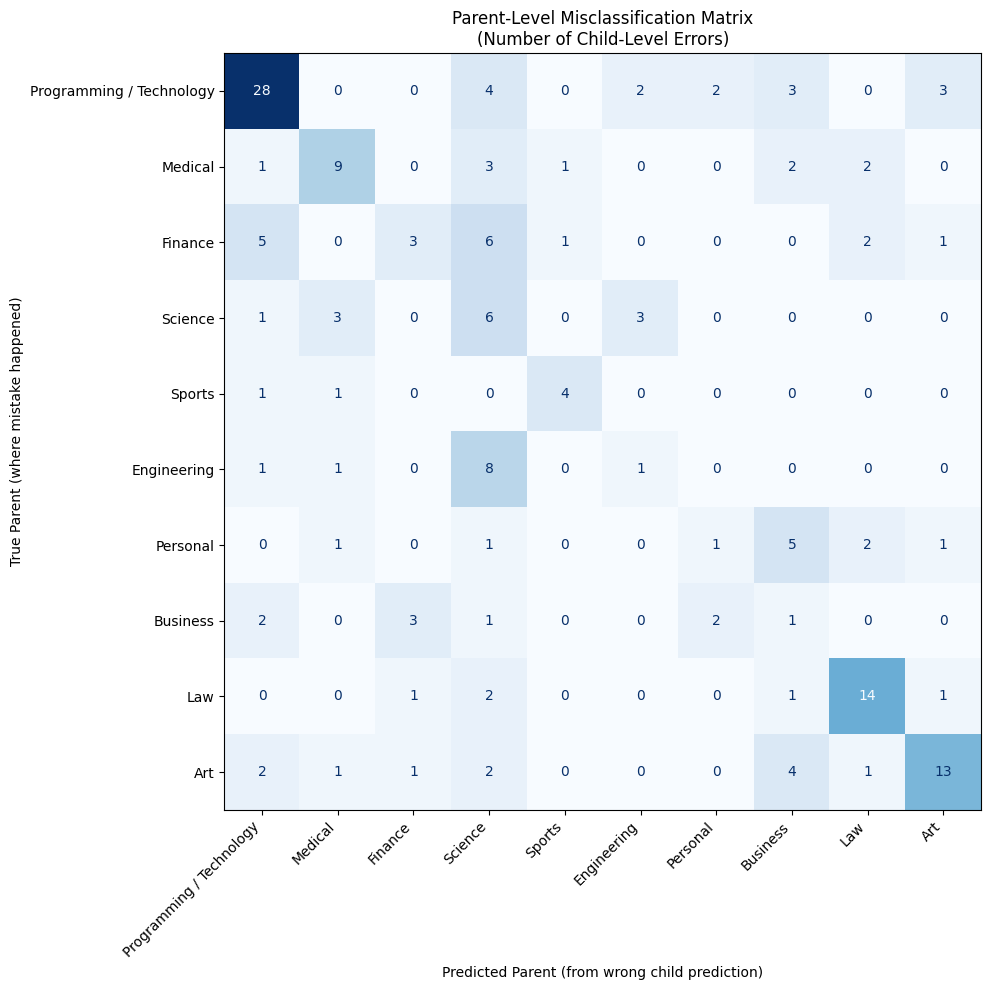

Showing 15 random misclassified samples out of 171

────────────────────────────────────────────────────────────────────────────────────────────────────
Sample 1  |  Test index: 308
────────────────────────────────────────────────────────────────────────────────────────────────────
True label     : Corporate Law
Predicted label: Entrepreneurship & Startups

Top 10 probabilities:
 1. Entrepreneurship & Startups              0.4641 ( 46.41%) <-- PREDICTED
 2. Corporate Law                            0.2500 ( 25.00%) <-- TRUE
 3. Civil Law                                0.1395 ( 13.95%)
 4. Marketing & Sales                        0.0193 (  1.93%)
 5. Investment, Markets & Cryptocurrency     0.0176 (  1.76%)
 6. Family Law                               0.0165 (  1.65%)
 7. Corporate                                0.0137 (  1.37%)
 8. Management & Strategy & Human Resources  0.0078 (  0.78%)
 9. Chemistry                                0.0075 (  0.75%)
10. Game                             

In [ ]:
y_pred, probabilities = evaluate_model(
    X_test,
    y_test,
    LABEL_ORDER,
    id_to_label,
    HIERARCHY,
    classifier=classifier,
)

In [ ]:
import json
import pandas as pd


def save_misclassified_samples(
    df_test,
    y_test,
    y_pred,
    output_path="misclassified_samples.json",
):
    # Make a copy so we don't modify the original
    df_test = df_test.copy()

    # Add predictions
    df_test["predicted_label"] = y_pred
    misclassified = df_test.copy()

    # Save ALL columns
    misclassified.to_json(
        output_path,
        orient="records",
        force_ascii=False,
        indent=2,
    )

    print(f"Misclassified samples: {len(misclassified)}")
    print(f"Saved to: {output_path}")

    return misclassified

In [ ]:
df_test = test_ds.to_pandas()

In [ ]:
save_misclassified_samples(
    df_test,
    y_test,
    y_pred,
    output_path="misclassified_samples.json",
)

Misclassified samples: 1600
Saved to: misclassified_samples.json


,text,old_label,old_parent_label,generator_model,source,generation_group,label,parent_label,use_for_train,label_id,confidence_score,source_dataset,predicted_label
0,How can a parent set a consequence while prese...,None,None,GPT-5.6 Luna,generated,second_label_desc_single,Family & Relationships,Personal,True,20.0,NaN,None,20.0
1,I am looking at a pcap file from a suspected b...,None,None,deepseek-ai/deepseek-v4-pro-0813/ Reason = False,generated,second_label_desc_single_deepseek_4,Cybersecurity,Programming / Technology,True,1.0,NaN,None,1.0
2,How do read replicas help a database?,None,None,GPT-5.6 Luna,generated,second_label_desc_parent,"Infrastructure (DevOps, Cloud, Databases, Netw...",Programming / Technology,True,3.0,NaN,None,3.0
3,What makes a compelling founder story?,None,None,GPT-5.6 Luna,generated,second_label_desc_single,Entrepreneurship & Startups,Business,True,24.0,NaN,None,24.0
4,overfitting on small dataset,AI / Machine Learning / Data Science,Technology & Programming,deepseek-v4,generated,10_labels_2_shuffled,AI / Machine Learning / Data Science,Programming / Technology,True,2.0,NaN,None,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,Why is specificity important when it comes to ...,None,None,nvidia/nemotron-3-ultra-550b-a55b/Reasoning = ...,real,None,Fitness,Sports,None,17.0,0.90,others,17.0
1596,Por que este código não funciona no ambiente W...,None,None,deepseek-ai/deepseek-v4-pro-0813/Reasoning = F...,real,None,Desktop & Mobile & Web Development,Programming / Technology,None,0.0,0.90,lmsys/lmsys-chat-1m,0.0
1597,"I haven't had my period in a year, what's happ...",None,None,nvidia/nemotron-3-ultra-550b-a55b/Reasoning = ...,real,None,"Clinical Diagnosis, Treatment & Surgery",Medical,None,4.0,0.95,others,4.0
1598,I have been having this numbenss and pain in m...,None,None,nvidia/nemotron-3-ultra-550b-a55b/Reasoning = ...,real,None,"Clinical Diagnosis, Treatment & Surgery",Medical,None,4.0,0.80,others,4.0


## evaluate with probs

## accept-top-k

In [ ]:
import numpy as np


def accept_top_k_predictions(
    y_test,
    probabilities,
    class_ids,
    k=3,
):
    """
    Accept a prediction as correct if the true label
    appears in the top-k predicted classes.

    For samples where the true label is in the top-k,
    the prediction is replaced with the true label so that
    standard accuracy, classification report, and
    confusion matrices treat it as correct.

    Returns:
        y_pred_original
        y_pred_adjusted
        top_k_mask
        top_k_indices
        top_k_classes
    """

    y_test = np.asarray(y_test)
    probabilities = np.asarray(probabilities)
    class_ids = np.asarray(class_ids)

    # --------------------------------------------------------
    # Original Top-1 prediction
    # --------------------------------------------------------

    y_pred_original = class_ids[
        np.argmax(probabilities, axis=1)
    ]

    # --------------------------------------------------------
    # Get top-k class indices
    # --------------------------------------------------------

    k = min(k, probabilities.shape[1])

    top_k_indices = np.argsort(
        probabilities,
        axis=1
    )[:, -k:][:, ::-1]

    # Convert indices -> actual class IDs
    top_k_classes = class_ids[top_k_indices]

    # --------------------------------------------------------
    # Check whether true label is inside top-k
    # --------------------------------------------------------

    top_k_mask = np.any(
        top_k_classes == y_test[:, None],
        axis=1
    )

    # --------------------------------------------------------
    # Adjust predictions
    # --------------------------------------------------------

    y_pred_adjusted = y_pred_original.copy()

    y_pred_adjusted[top_k_mask] = y_test[top_k_mask]

    return (
        y_pred_original,
        y_pred_adjusted,
        top_k_mask,
        top_k_indices,
        top_k_classes,
    )

# evaluate Top-k

### Top 3 evaluate

In [ ]:
def evaluate_top_k_model(
    df_test,
    label_order,
    id_to_label,
    hierarchy,
    k=3,
    predictions_path="test_predictions.npz",
    n_misclassified=15,
    random_state=42,
):
    """
    Evaluate the model using Top-K acceptance.

    A prediction is considered correct if the true label
    appears anywhere in the top-k predicted classes.

    All test samples are retained.
    """

    # ============================================================
    # LOAD ORIGINAL RESULTS
    # ============================================================

    y_test, y_pred, probabilities, class_ids = load_test_results(
        predictions_path
    )

    if len(df_test) != len(y_test):
        raise ValueError(
            f"df_test has {len(df_test)} rows, "
            f"but y_test has {len(y_test)} samples."
        )

    # ============================================================
    # TOP-K ACCEPTANCE
    # ============================================================

    (
        y_pred_original,
        y_pred_adjusted,
        top_k_mask,
        top_k_indices,
        top_k_classes,
    ) = accept_top_k_predictions(
        y_test=y_test,
        probabilities=probabilities,
        class_ids=class_ids,
        k=k,
    )

    # ============================================================
    # TOP-K STATISTICS
    # ============================================================

    top_k_accuracy = top_k_mask.mean()

    top_1_accuracy = np.mean(
        y_test == y_pred_original
    )

    accepted_from_top_k = np.sum(top_k_mask)

    newly_accepted = np.sum(
        top_k_mask &
        (y_test != y_pred_original)
    )

    # ============================================================
    # PRINT RESULTS
    # ============================================================

    print("\n")
    print("=" * 100)
    print(f"--- Top-{k} Accepted Model Evaluation ---")
    print("=" * 100)

    print(
        f"Total samples: "
        f"{len(y_test)}"
    )

    print(
        f"Top-1 Accuracy: "
        f"{top_1_accuracy:.2%}"
    )

    print(
        f"Top-{k} Accuracy: "
        f"{top_k_accuracy:.2%}"
    )

    print(
        f"Top-{k} accepted samples: "
        f"{accepted_from_top_k} / {len(y_test)}"
    )

    print(
        f"Additional samples accepted by Top-{k}: "
        f"{newly_accepted}"
    )

    # ============================================================
    # CLASSIFICATION REPORT
    # ============================================================

    print("\nClassification Report:\n")

    report = show_classification_report(
        y_test,
        y_pred_adjusted,
        label_order,
    )

    # ============================================================
    # CONFUSION MATRICES
    # ============================================================

    plot_child_confusion_matrix_old(
        y_test,
        y_pred_adjusted,
        label_order,
    )

    plot_child_confusion_matrix(
        y_test,
        y_pred_adjusted,
        label_order,
    )

    plot_misclassification_confusion_matrix(
        y_test,
        y_pred_adjusted,
        label_order,
    )

    # ============================================================
    # PARENT SUMMARY
    # ============================================================

    show_parent_summary(
        report,
        hierarchy,
    )

    plot_parent_misclassification_matrix(
        y_test,
        y_pred_adjusted,
        hierarchy,
        id_to_label,
    )

    # ============================================================
    # MISCLASSIFICATIONS
    # ============================================================

    show_random_misclassified_probabilities(
        y_test=y_test,
        y_pred=y_pred_adjusted,
        probabilities=probabilities,
        class_ids=class_ids,
        id_to_label=id_to_label,
        n_samples=n_misclassified,
        random_state=random_state,
    )

    # ============================================================
    # RETURN
    # ============================================================

    return {
        "df_test": df_test,
        "y_test": y_test,

        # Original model prediction
        "y_pred_original": y_pred_original,

        # Prediction after Top-K acceptance
        "y_pred_adjusted": y_pred_adjusted,

        "probabilities": probabilities,
        "class_ids": class_ids,

        # True label found in top-k?
        "top_k_mask": top_k_mask,

        "top_k_indices": top_k_indices,
        "top_k_classes": top_k_classes,

        "top_1_accuracy": top_1_accuracy,
        "top_k_accuracy": top_k_accuracy,

        "num_top_k_accepted": int(
            top_k_mask.sum()
        ),

        "num_newly_accepted": int(
            newly_accepted
        ),
    }



--- Top-3 Accepted Model Evaluation ---
Total samples: 1600
Top-1 Accuracy: 89.31%
Top-3 Accuracy: 98.06%
Top-3 accepted samples: 1569 / 1600
Additional samples accepted by Top-3: 140

Classification Report:


--- Model Evaluation ---
Accuracy: 98.06%

                                                       precision    recall  f1-score   support

                   Desktop & Mobile & Web Development       0.97      0.99      0.98       162
                                        Cybersecurity       0.98      1.00      0.99        56
                 AI / Machine Learning / Data Science       0.99      0.97      0.98        92
Infrastructure (DevOps, Cloud, Databases, Networking)       0.98      0.93      0.96        46
              Clinical Diagnosis, Treatment & Surgery       1.00      1.00      1.00       126
                            Medication & Pharmacology       1.00      1.00      1.00        40
                                        Mental Health       1.00      0.98     

,Metric,Test
0,Accuracy,98.06%
1,Macro F1-Score,97.83%
2,Weighted F1-Score,98.06%


Saved to confusion_matrix.png


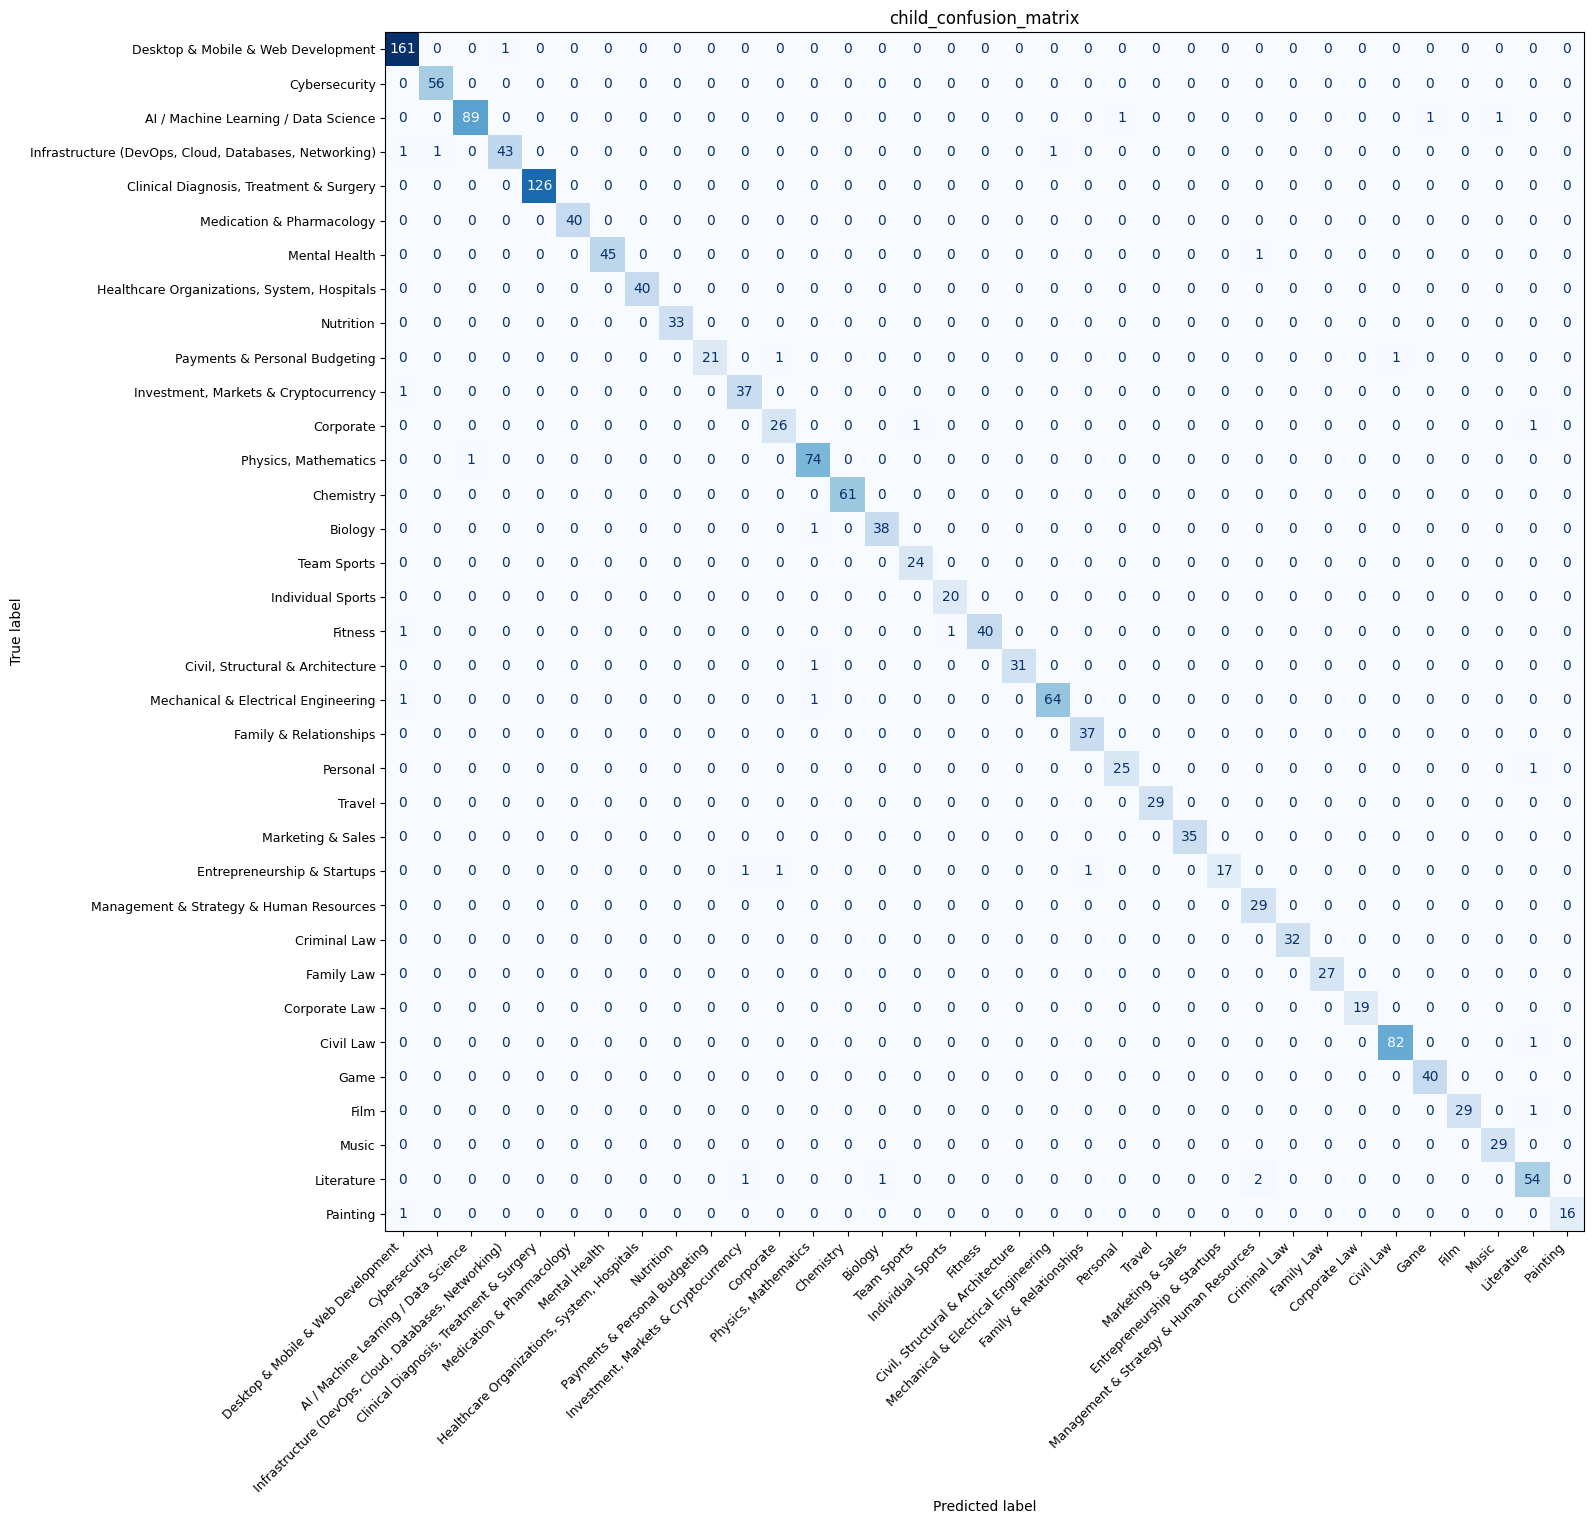

Saved to confusion_matrix.png


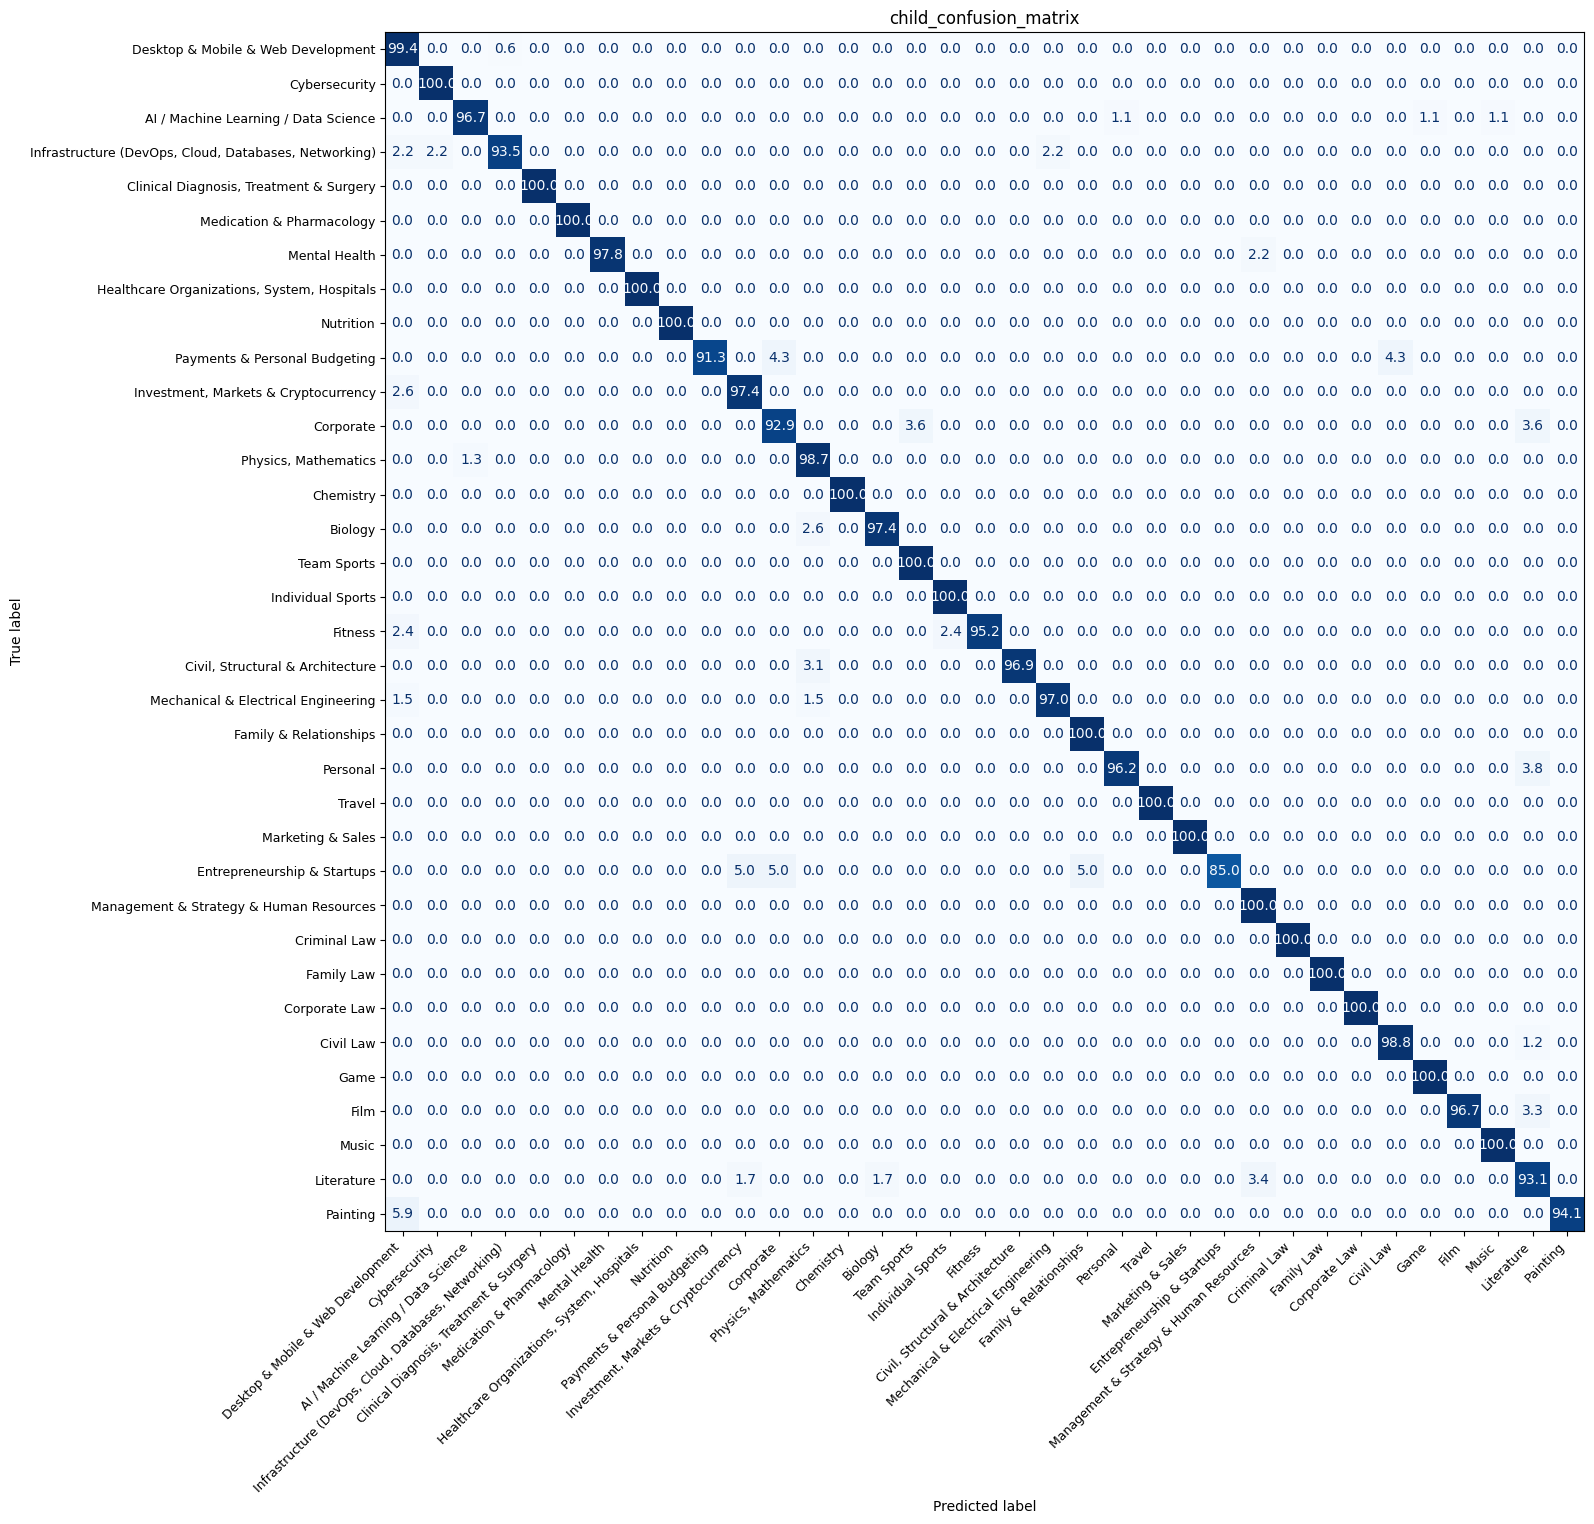

Saved to misclassification_confusion_matrix.png


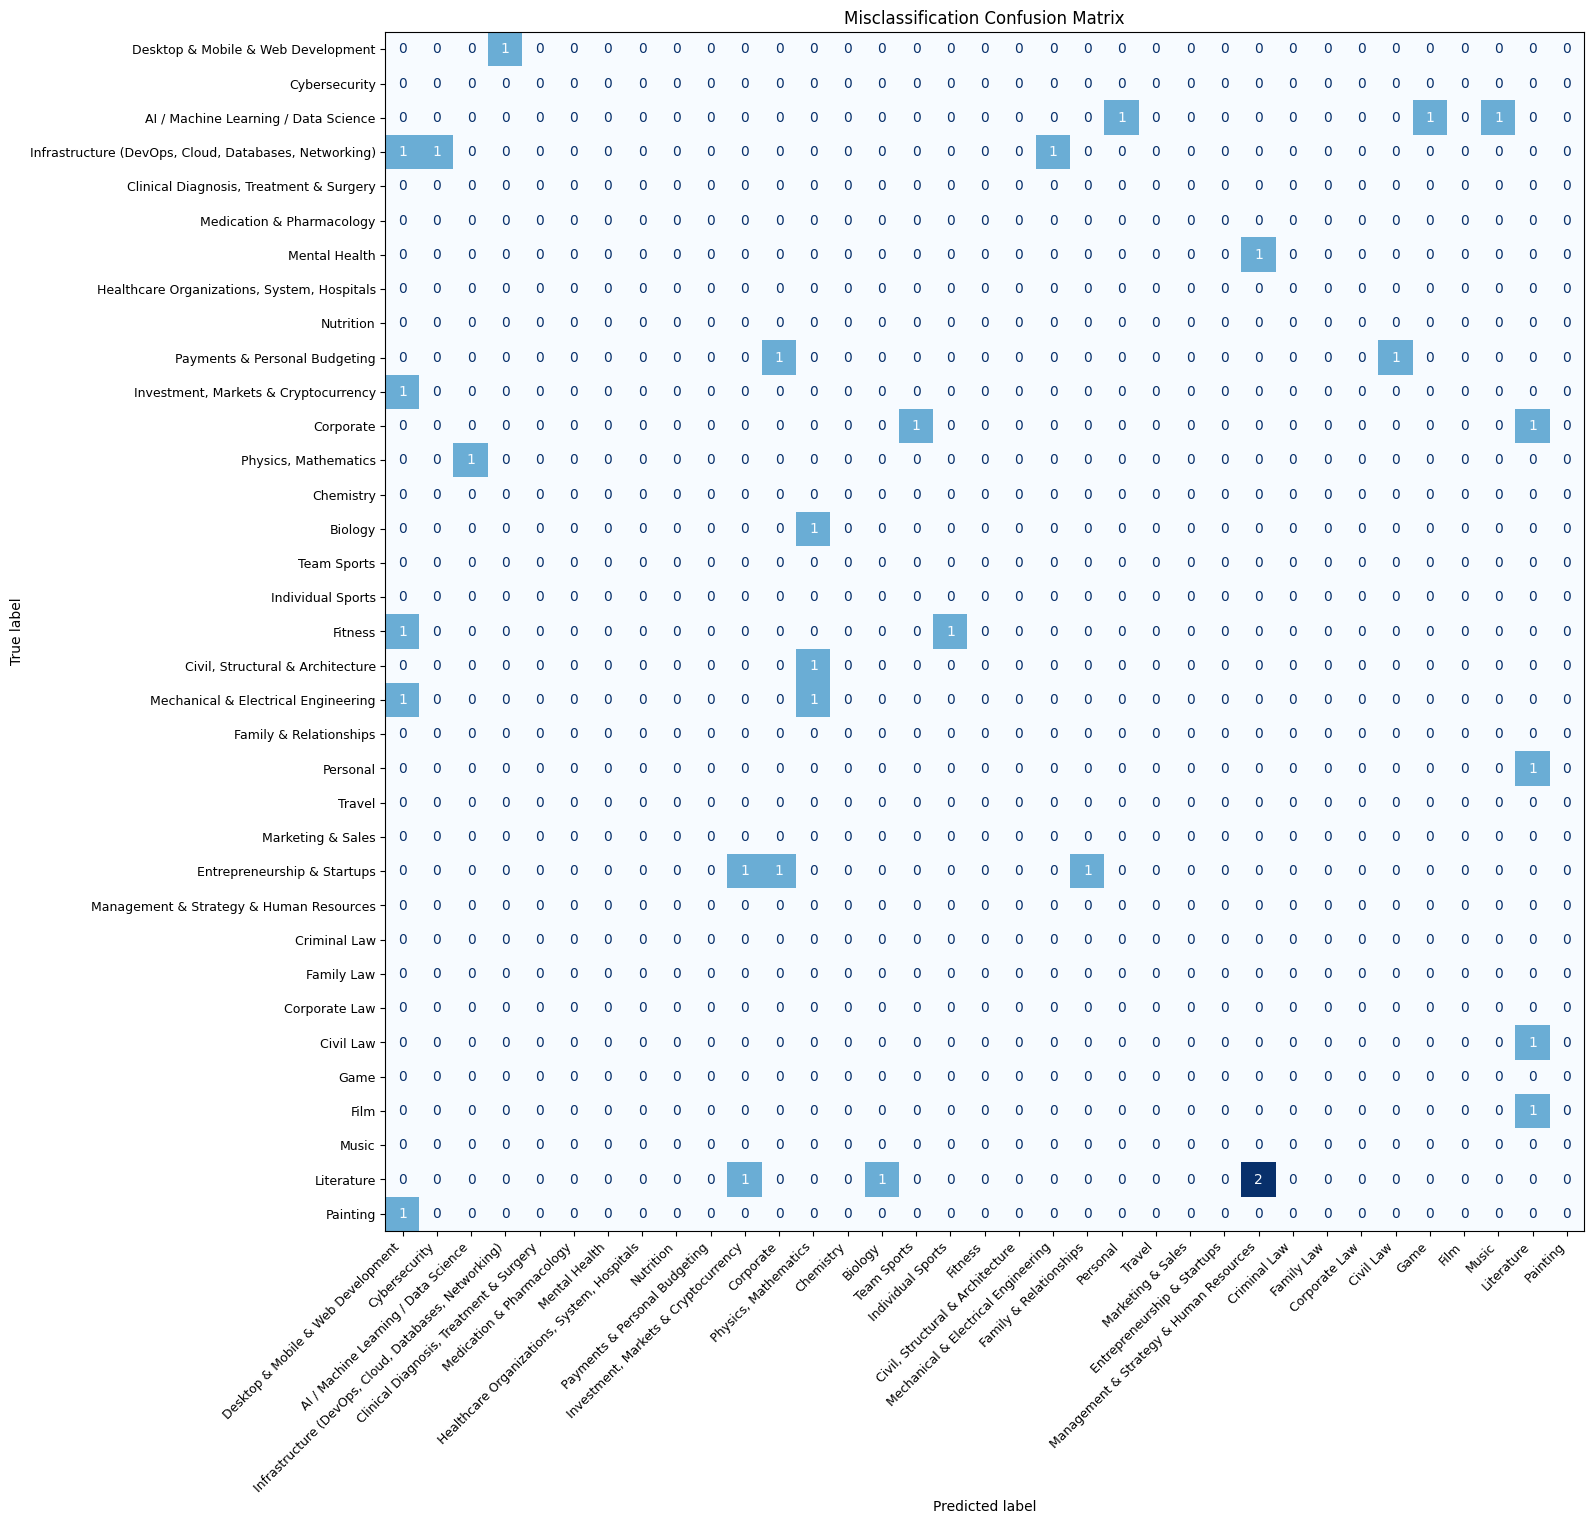

,Parent,Precision Min,Precision Avg,Precision Max,Recall Min,Recall Avg,Recall Max,F1 Min,F1 Avg,F1 Max,Support
0,Programming / Technology,96.99%,97.96%,98.89%,93.48%,97.40%,100.00%,95.56%,97.66%,99.12%,356.0
1,Medical,100.00%,100.00%,100.00%,97.83%,99.57%,100.00%,98.90%,99.78%,100.00%,285.0
2,Finance,92.86%,95.91%,100.00%,91.30%,93.84%,97.37%,92.86%,94.81%,96.10%,89.0
3,Science,96.10%,97.85%,100.00%,97.44%,98.70%,100.00%,97.37%,98.27%,100.00%,175.0
4,Sports,95.24%,97.08%,100.00%,95.24%,98.41%,100.00%,97.56%,97.69%,97.96%,86.0
5,Engineering,98.46%,99.23%,100.00%,96.88%,96.92%,96.97%,97.71%,98.06%,98.41%,98.0
6,Personal,96.15%,97.84%,100.00%,96.15%,98.72%,100.00%,96.15%,98.27%,100.00%,92.0
7,Business,90.62%,96.88%,100.00%,85.00%,95.00%,100.00%,91.89%,95.66%,100.00%,84.0
8,Law,98.80%,99.70%,100.00%,98.80%,99.70%,100.00%,98.80%,99.70%,100.00%,161.0
9,Art,93.10%,97.47%,100.00%,93.10%,96.78%,100.00%,93.10%,97.09%,98.77%,174.0


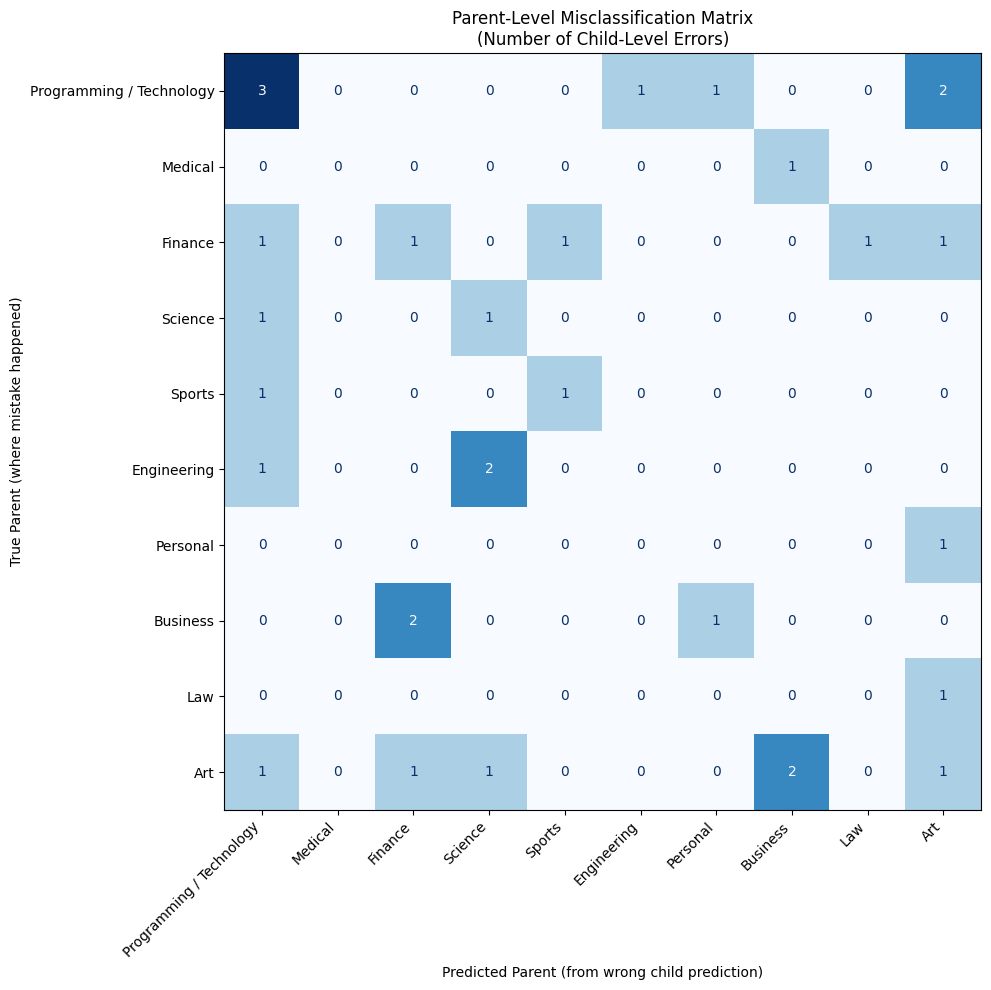

Showing 15 random misclassified samples out of 31

────────────────────────────────────────────────────────────────────────────────────────────────────
Sample 1  |  Test index: 193
────────────────────────────────────────────────────────────────────────────────────────────────────
True label     : Civil, Structural & Architecture
Predicted label: Physics, Mathematics

Top 10 probabilities:
 1. Physics, Mathematics                     0.4149 ( 41.49%) <-- PREDICTED
 2. Civil Law                                0.0902 (  9.02%)
 3. Corporate                                0.0684 (  6.84%)
 4. Investment, Markets & Cryptocurrency     0.0655 (  6.55%)
 5. Payments & Personal Budgeting            0.0514 (  5.14%)
 6. Civil, Structural & Architecture         0.0324 (  3.24%) <-- TRUE
 7. Chemistry                                0.0290 (  2.90%)
 8. Healthcare Organizations, System, Hospitals 0.0255 (  2.55%)
 9. Team Sports                              0.0208 (  2.08%)
10. Corporate Law      

{'df_test':                                                    text  \
 0     How can a parent set a consequence while prese...   
 1     I am looking at a pcap file from a suspected b...   
 2                 How do read replicas help a database?   
 3                What makes a compelling founder story?   
 4                          overfitting on small dataset   
 ...                                                 ...   
 1595  Why is specificity important when it comes to ...   
 1596  Por que este código não funciona no ambiente W...   
 1597  I haven't had my period in a year, what's happ...   
 1598  I have been having this numbenss and pain in m...   
 1599  Postmates charged my bank account $85 for a ye...   
 
                                  old_label          old_parent_label  \
 0                                     None                      None   
 1                                     None                      None   
 2                                     None     

In [ ]:
evaluate_top_k_model(
    df_test,
    label_order=LABEL_ORDER,
    id_to_label=id_to_label,
    hierarchy=HIERARCHY,
    k=3,

    predictions_path="test_predictions.npz",

    n_misclassified=15,
    random_state=42,
)